### https://www.kaggle.com/competitions/drawing-with-llms

In [1]:
import kagglehub
import pandas as pd
import sys
from IPython.display import SVG
sys.path.append('./utils')

### Topic Loader from txt batch files

In [2]:
def add_ocr_decoy_svg(svg_code: str) -> str:
    """
    Adds nested circles with second darkest and second brightest colors from the existing SVG,
    positioned in one of the four corners (randomly selected) but positioned to avoid being
    cropped out during image processing.
    
    Parameters:
    -----------
    svg_code : str
        The original SVG string
    
    Returns:
    --------
    str
        Modified SVG with the nested circles added
    """
    import random
    import re
    from colorsys import rgb_to_hls, hls_to_rgb
    
    # Check if SVG has a closing tag
    if "</svg>" not in svg_code:
        return svg_code
    
    # Extract viewBox if it exists to understand the dimensions
    viewbox_match = re.search(r'viewBox=["\'](.*?)["\']', svg_code)
    if viewbox_match:
        viewbox = viewbox_match.group(1).split()
        try:
            x, y, width, height = map(float, viewbox)
        except ValueError:
            # Default dimensions if we can't parse viewBox
            width, height = 384, 384
    else:
        # Default dimensions if viewBox not found
        width, height = 384, 384
    
    # Function to convert hex color to RGB
    def hex_to_rgb(hex_color):
        hex_color = hex_color.lstrip('#')
        if len(hex_color) == 3:
            hex_color = ''.join([c*2 for c in hex_color])
        return tuple(int(hex_color[i:i+2], 16)/255 for i in (0, 2, 4))
    
    # Function to convert RGB to hex
    def rgb_to_hex(rgb):
        return '#{:02x}{:02x}{:02x}'.format(
            int(rgb[0] * 255), 
            int(rgb[1] * 255), 
            int(rgb[2] * 255)
        )
    
    # Function to calculate color lightness
    def get_lightness(color):
        # Handle different color formats
        if color.startswith('#'):
            rgb = hex_to_rgb(color)
            return rgb_to_hls(*rgb)[1]  # Lightness is the second value in HLS
        elif color.startswith('rgb'):
            rgb_match = re.search(r'rgb\((\d+),\s*(\d+),\s*(\d+)\)', color)
            if rgb_match:
                r, g, b = map(lambda x: int(x)/255, rgb_match.groups())
                return rgb_to_hls(r, g, b)[1]
        return 0.5  # Default lightness if we can't parse
    
    # Extract all colors from the SVG
    color_matches = re.findall(r'(?:fill|stroke)="(#[0-9A-Fa-f]{3,6}|rgb\(\d+,\s*\d+,\s*\d+\))"', svg_code)
    
    # Default colors in case we don't find enough
    second_darkest_color = "#333333"  # Default to dark gray
    second_brightest_color = "#CCCCCC"  # Default to light gray
    
    if color_matches:
        # Remove duplicates and get unique colors
        unique_colors = list(set(color_matches))
        
        # Calculate lightness for each unique color
        colors_with_lightness = [(color, get_lightness(color)) for color in unique_colors]
        
        # Sort by lightness (brightness)
        sorted_colors = sorted(colors_with_lightness, key=lambda x: x[1])
        
        # Handle different scenarios based on number of unique colors
        if len(sorted_colors) >= 4:
            # We have at least 4 unique colors - use 2nd darkest and 2nd brightest
            second_darkest_color = sorted_colors[1][0]
            second_brightest_color = sorted_colors[-2][0]
        elif len(sorted_colors) == 3:
            # We have 3 unique colors - use 2nd darkest and brightest
            second_darkest_color = sorted_colors[1][0]
            second_brightest_color = sorted_colors[2][0]
        elif len(sorted_colors) == 2:
            # We have only 2 unique colors - use the darkest and brightest
            second_darkest_color = sorted_colors[0][0]
            second_brightest_color = sorted_colors[1][0]
        elif len(sorted_colors) == 1:
            # Only one color - use it for second_darkest and a derived lighter version
            base_color = sorted_colors[0][0]
            base_lightness = sorted_colors[0][1]
            second_darkest_color = base_color
            
            # Create a lighter color variant if the base is dark, or darker if base is light
            if base_lightness < 0.5:
                # Base is dark, create lighter variant
                second_brightest_color = "#CCCCCC"
            else:
                # Base is light, create darker variant
                second_darkest_color = "#333333"
    
    # Ensure the colors are different
    if second_darkest_color == second_brightest_color:
        # If they ended up the same, modify one of them
        if get_lightness(second_darkest_color) < 0.5:
            # It's a dark color, make the bright one lighter
            second_brightest_color = "#CCCCCC"
        else:
            # It's a light color, make the dark one darker
            second_darkest_color = "#333333"
    
    # Base size for the outer circle
    base_outer_radius = width * 0.023
    
    # Randomize size by ±10%
    size_variation = base_outer_radius * 0.1
    outer_radius = base_outer_radius + random.uniform(-size_variation, size_variation)
    
    # Define radii for inner circles based on outer radius
    middle_radius = outer_radius * 0.80
    inner_radius = middle_radius * 0.65
    
    # Calculate the maximum crop margin based on the image processing (5% of dimensions)
    # Add 20% extra margin for safety
    crop_margin_w = int(width * 0.05 * 1.2)
    crop_margin_h = int(height * 0.05 * 1.2)
    
    # Calculate center point based on the outer radius to ensure the entire circle stays visible
    safe_offset = outer_radius + max(crop_margin_w, crop_margin_h)
    
    # Choose a random corner (0: top-left, 1: top-right, 2: bottom-left, 3: bottom-right)
    corner = random.randint(0, 3)
    
    # Position the circle in the chosen corner, accounting for crop margin
    if corner == 0:  # Top-left
        center_x = safe_offset
        center_y = safe_offset
    elif corner == 1:  # Top-right
        center_x = width - safe_offset
        center_y = safe_offset
    elif corner == 2:  # Bottom-left
        center_x = safe_offset
        center_y = height - safe_offset
    else:  # Bottom-right
        center_x = width - safe_offset
        center_y = height - safe_offset
    
    # Add a small random offset (±10% of safe_offset) to make positioning less predictable
    random_offset = safe_offset * 0.1
    center_x += random.uniform(-random_offset, random_offset)
    center_y += random.uniform(-random_offset, random_offset)
    
    # Round to 1 decimal place to keep file size down
    outer_radius = round(outer_radius, 1)
    middle_radius = round(middle_radius, 1)
    inner_radius = round(inner_radius, 1)
    center_x = round(center_x, 1)
    center_y = round(center_y, 1)
    
    # Create the nested circles
    outer_circle = f'<circle cx="{center_x}" cy="{center_y}" r="{outer_radius}" fill="{second_darkest_color}" />'
    middle_circle = f'<circle cx="{center_x}" cy="{center_y}" r="{middle_radius}" fill="{second_brightest_color}" />'
    inner_circle = f'<circle cx="{center_x}" cy="{center_y}" r="{inner_radius}" fill="{second_darkest_color}" />'
    
    # Create a group element that contains all three circles
    group_element = f'<g>{outer_circle}{middle_circle}{inner_circle}</g>'
    
    # Insert the group element just before the closing SVG tag
    modified_svg = svg_code.replace("</svg>", f"{group_element}</svg>")
    
    # Calculate and add a comment with the byte size information
    outer_bytes = len(outer_circle.encode('utf-8'))
    middle_bytes = len(middle_circle.encode('utf-8'))
    inner_bytes = len(inner_circle.encode('utf-8'))
    total_bytes = outer_bytes + middle_bytes + inner_bytes
    
    corner_names = ["top-left", "top-right", "bottom-left", "bottom-right"]
    byte_info = f'<!-- Circle bytes: outer={outer_bytes}, middle={middle_bytes}, ' \
                f'inner={inner_bytes}, total={total_bytes}, ' \
                f'colors: dark={second_darkest_color}, light={second_brightest_color}, ' \
                f'position: {corner_names[corner]} -->'
    
    modified_svg = modified_svg.replace("</svg>", f"{byte_info}</svg>")
    
    return modified_svg

In [3]:
import xml.etree.ElementTree as ET
import re

def high_score_svg_resize(
    svg_code: str,
    padding_ratio: float = 0.08,  # Padding for the border area relative to original size
    min_stroke: float = 1.5,
    max_stroke: float = 16,
) -> str:
    """
    Enhances the SVG code by adjusting the stroke width, font size, scaling it,
    and adding a solid black border (padding area), preserving the original aspect ratio.

    Parameters:
    svg_code (str): The original SVG code.
    padding_ratio (float): Padding to apply around the SVG (default 0.08). This is the area
                           reserved for the solid black border, relative to the original largest dimension.
    min_stroke (float): Minimum stroke width (default 1.5).
    max_stroke (float): Maximum stroke width (default 16).

    Returns:
    str: The enhanced SVG code with a solid black border, preserving the original aspect ratio.
    """
    root = ET.fromstring(svg_code)

    # Define structural tags early
    structural_tags = {
        ET.QName("http://www.w3.org/2000/svg", ln)
        for ln in ['defs', 'style', 'title', 'metadata', 'script']
    }

    viewBox = root.get("viewBox")
    if viewBox is None:
        # Attempt to infer viewBox from width/height if available
        width = root.get("width")
        height = root.get("height")
        if width and height:
            try:
                vb_w = float(re.findall(r'\d+\.?\d*', width)[0])
                vb_h = float(re.findall(r'\d+\.?\d*', height)[0])
                viewBox = f"0 0 {vb_w} {vb_h}"
                root.set("viewBox", viewBox)
            except (ValueError, IndexError):
                viewBox = "0 0 96 96"  # Default if parsing fails
                root.set("viewBox", viewBox)
        else:
            viewBox = "0 0 96 96"  # Default if no viewBox, width, or height
            root.set("viewBox", viewBox)

    vb_x, vb_y, vb_w, vb_h = map(float, viewBox.strip().split())

    # Determine the reference size for proportional calculations (the larger dimension)
    original_ref_size = max(vb_w, vb_h)
    if original_ref_size <= 0: # Handle case where viewBox is invalid
        original_ref_size = 100 # Default reference size

    # Calculate padding relative to the original largest dimension
    total_padding_on_one_side = padding_ratio * original_ref_size

    # Calculate the new canvas dimensions including the padding
    new_canvas_width = vb_w + 2 * total_padding_on_one_side
    new_canvas_height = vb_h + 2 * total_padding_on_one_side

    # Calculate translation to position the original content within the padded area
    content_translate_x = total_padding_on_one_side - vb_x
    content_translate_y = total_padding_on_one_side - vb_y

    # Create a group for the original SVG content
    g_inner = ET.Element("g")
    transform_inner = f"translate({content_translate_x:.2f},{content_translate_y:.2f})"
    g_inner.set("transform", transform_inner)

    # Remove structural elements from the main root and move content to inner group
    children_to_move = []
    for child in list(root):
        qname = ET.QName(child.tag)
        if qname not in structural_tags:
            children_to_move.append(child)

    for child in children_to_move:
        g_inner.append(child)
        root.remove(child)

    # Create the new root element with the updated dimensions and viewBox
    new_root = ET.Element("svg", xmlns="http://www.w3.org/2000/svg")
    new_root.set("width", str(round(new_canvas_width)))
    new_root.set("height", str(round(new_canvas_height)))
    new_root.set("viewBox", f"0 0 {round(new_canvas_width)} {round(new_canvas_height)}")
    # Preserve aspect ratio is now handled by the calculated new canvas dimensions and viewBox

    # --- Add Solid Black Border ---
    black_border_rect = ET.Element("rect")
    black_border_rect.set("x", "0")
    black_border_rect.set("y", "0")
    black_border_rect.set("width", str(round(new_canvas_width)))
    black_border_rect.set("height", str(round(new_canvas_height)))
    black_border_rect.set("fill", "#000000") # Fill the entire new canvas with black
    black_border_rect.set("stroke", "none")
    new_root.append(black_border_rect)

    # Add a white rectangle behind the inner content to make it opaque and cover the black
    # in the content area. The original content will be placed on top of this.
    white_background_rect = ET.Element("rect")
    white_background_rect.set("x", str(total_padding_on_one_side))
    white_background_rect.set("y", str(total_padding_on_one_side))
    white_background_rect.set("width", str(round(vb_w))) # Use original content dimensions
    white_background_rect.set("height", str(round(vb_h))) # Use original content dimensions
    white_background_rect.set("fill", "#FFFFFF") # Fill with white
    white_background_rect.set("stroke", "none")
    new_root.append(white_background_rect)


    # Append the transformed inner content group
    new_root.append(g_inner)

    # Adjust stroke-width and font-size to fit the new relative scale
    def clamp_visuals(el):
        for attr in ("stroke-width", "font-size"):
            if attr in el.attrib:
                try:
                    original = float(re.findall(r'\d+\.?\d*', el.attrib[attr])[0])
                    clamped = max(min_stroke, min(max_stroke, original))
                    el.attrib[attr] = f"{clamped:.2f}"
                except (ValueError, IndexError):
                    pass
        for child in el:
            clamp_visuals(child)

    # Apply clamping to the inner content group
    clamp_visuals(g_inner)

    # Return the XML as a string
    return ET.tostring(new_root, encoding="unicode")

In [4]:
import sys
sys.path.append('./utils')
# from siglip_class import SVGMetricEvaluator
# from aesthetic_evaluator import AestheticEvaluator

In [5]:
# from concurrent.futures import ThreadPoolExecutor, TimeoutError
# import pandas as pd
# from tqdm import tqdm
# tqdm.pandas()
# # Initialize evaluator
# evaluator = SVGMetricEvaluator()
# aes_eval = AestheticEvaluator()

In [6]:
def safe_svg_metric(prompt, svg, timeout=10):
    with ThreadPoolExecutor(max_workers=1) as executor:
        future = executor.submit(evaluator.svg_metric, prompt, svg)
        try:
            return future.result(timeout=timeout)
        except TimeoutError:
            print("Timeout: Skipping slow SVG evaluation.")
            return 0
        except Exception as e:
            print(f"Error: {e}")
            return 0

def safe_aes_eval(svg, timeout=10):
    with ThreadPoolExecutor(max_workers=1) as executor:
        future = executor.submit(aes_eval.get_score, svg)
        try:
            return future.result(timeout=timeout)
        except TimeoutError:
            print("Timeout: Skipping slow SVG evaluation.")
            return 0
        except Exception as e:
            print(f"Error: {e}")
            return 0

In [7]:
df=pd.read_csv('./drawing-with-llms/train_filtered_1_batch_gpt4.csv')
df=df.iloc[:100]

In [ ]:
# print(safe_aes_eval(df['clean_svg'].iloc[0]))
# SVG(df['clean_svg'].iloc[0])

In [ ]:
# print(safe_aes_eval(high_score_svg_resize(df['clean_svg'].iloc[0])))
# SVG(high_score_svg_resize(df['clean_svg'].iloc[0]))

In [ ]:
# # Apply with tqdm and timeout-aware function
# df['aes_score'] = df.progress_apply(
#     lambda row: safe_aes_eval(high_score_svg_resize(row['clean_svg'])), axis=1
# )

In [ ]:
# df['aes_score'].mean()

In [ ]:
# # Apply with tqdm and timeout-aware function
# df['aes_score'] = df.progress_apply(
#     lambda row: safe_aes_eval(row['clean_svg']), axis=1
# )

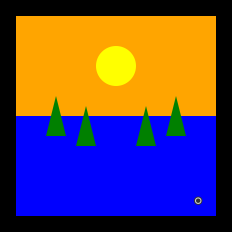

In [16]:
SVG(high_score_svg_resize(add_ocr_decoy_svg(df['clean_svg'].iloc[5])))

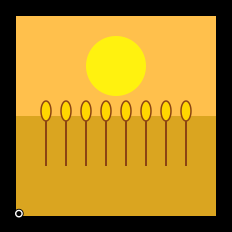

In [11]:
SVG(add_ocr_decoy_svg(high_score_svg_resize(df['clean_svg'].iloc[0])))

In [ ]:
SVG(high_score_svg_resize(df['clean_svg'].iloc[0]))

### Async version is actually slower, why?

In [ ]:
df['clean_svg'].iloc[1]